<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="800">

# Домашнее задание 4: АБ-тест и рок-кривые
</center>

**ФИО:**

## Общая информация

__Дата выдачи:__ 14.03.2026

__Дедлайн:__ 23:59MSK 12.04.2026

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from collections import defaultdict
import pandas as pd

На семинаре мы попытались разобраться как устроена процедура АБ-тестирования. В этом задании мы попытаемся закрепить полученные знания и более аккуратно структурировать их.

### Кратко повторим теорию

Мы хотим выктить новую функциональность на сайте. Перед раскаткой нам хочется проверить, какой эффект мы оказываем на пользователя. Выделим две выборки: тестовую (treatment) и контрольную (control). Тестовой покажем новый сайт. Контрольной старый. Замерим инетерсующую нас метрику, нааример, время проведенной на сайте, в обеих группах:

$$
\begin{aligned}
&X^c_1, \ldots, X^c_{n_c} \sim iid (\mu_c, \sigma^2_c) \\
&X^t_1, \ldots, X^t_{n_t} \sim iid (\mu_t, \sigma^2_t)
\end{aligned}
$$

У выборок есть какие-то математические ожидания, дисперсии. Выборки собраны независимо друг от друга. Если их математические ожидания одинаковые, будем считать, что новая функциональность никак не повлияла на пользователей. Сформулируем это в виде нашей нулевой гипотезы:

$$
\begin{aligned}
&H_0: \hspace{2mm} \mu_c = \mu_t \\
&H_1: \hspace{2mm} \mu_c < \mu_t.
\end{aligned}
$$

Посчитаем по выборке расстояние между математическими ожиданиями $\hat \mu_t - \hat \mu_c$. Оно по ЦПТ имеет нормальное распределение с оценкой дисперсии $\frac{\hat{\sigma}^2_t}{n_t} + \frac{\hat{\sigma}^2_c}{n_c}$. Получается, что

$$
z = \frac{\hat \mu_t - \hat \mu_c}{\sqrt{\frac{\hat{\sigma}^2_t}{n_t} + \frac{\hat{\sigma}^2_c}{n_c}}} \sim N(0,1),
$$

при верности нулевой гипотезы и $n \to \infty$. Если это расстояние оказывается слишком большим, мы отказываемся верить в нулевую гипотезу. Эффект от новой функциональности есть. Будем сравнивать наблюдаемое значение $z$ с $z_{1 - \alpha},$ где уровень значимости $\alpha$ выберем до начала эксперимента.

- Если $z < z_{1 - \alpha},$ нулевая гипотеза не отвергается (похоже, что верна). Расстояние маленькое, разницы нет.
- Если $z > z_{1 - \alpha},$ выбираем альтернативу. У на есть значимый эффект на метрику, от веры в нулевую гипотезу придётся отказаться.

> Ничего не понятно? Тогда вам в лекции. Ниже подборка:  

- [Наша лекция про АБ]( )
- [Неделя про проверку гипотез с курсеры](https://www.youtube.com/watch?v=Zv-5gbJtofk&list=PLCf-cQCe1FRxTgNPwcRSkBjvtE8DEm7rU)


## Задания


__а) [1 балл]__ Реализуйте функцию для проверки гипотезы о равенстве математических ожиданий. Она должна принимать на вход две выборки и выдавать на выход наблюдаемое значение статистики `z_obs` и `p_value` для ситуаций с разными альтернативными гипотезами.

In [2]:
def asy_mean_test(x_control, x_treatment, alternative = 'larger'):
    n_c = len(x_control)
    n_t = len(x_treatment)

    mean_c = np.mean(x_control)
    mean_t = np.mean(x_treatment)

    var_c = np.var(x_control, ddof=1)
    var_t = np.var(x_treatment, ddof=1)

    se = np.sqrt(var_c/n_c + var_t/n_t)

    z_obs = (mean_t-mean_c)/se

    if alternative == 'larger':
        p_value = 1 - stats.norm.cdf(z_obs)
    elif alternative == 'smaller':
        p_value = stats.norm.cdf(z_obs)
    elif alternative == 'two-sided':
        p_value = 2*(1- stats.norm.cdf(np.abs(z_obs)))
    else:
        raise ValueError("alternative must be 'larger', 'smaller', or 'two-sided'")

    return z_obs, p_value

Если вы написали весь код выше корректно, то строки ниже сработают без проблем.

In [3]:
def gen_sample(n_obs, effect, p_control):
    p_treatment = p_control * (1 + effect)
    x_control = stats.bernoulli(p_control).rvs(n_obs)
    x_treatment = stats.bernoulli(p_treatment).rvs(n_obs)
    return x_control, x_treatment

In [4]:
# Проверка ситуации, когда верна нулевая гипотеза
_, pval = asy_mean_test(*gen_sample(10**5, 0, 0.2))
assert pval > 0.01

In [5]:
# Проверка ситуации, когда верна нулевая гипотеза
_, pval = asy_mean_test(*gen_sample(10**5, 0.1, 0.2))
assert pval < 0.01

Для простоты мы дальше будем работать с односторонней альтернативой и тестом для долей.

$$
\begin{aligned}
&H_0: \hspace{2mm} p_t = p_c \\
&H_1: \hspace{2mm} p_t > p_c
\end{aligned}
$$

__б) [2 балла]__ Предположим, что нулевая гипотеза верна. Как при верности нулевой гипотезы будут распределены `pvalue` и `z_obs`?  

С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$, постройте две гистограммы.

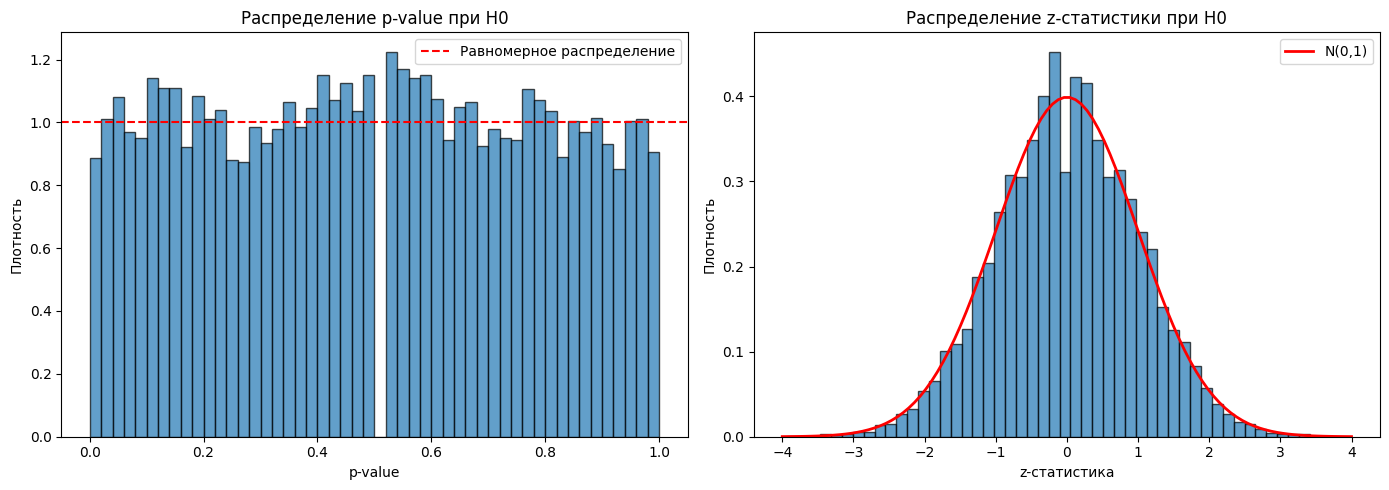

Среднее z-статистики: 0.0111
Дисперсия z-статистики: 0.9787


In [6]:
n_sim = 10**4
n_obs = 1000
p_control = 0.2
effect = 0

z_values = []
p_values = []

for _ in range(n_sim):
    x_control, x_treatment = gen_sample(n_obs, effect, p_control)
    z_obs, p_val = asy_mean_test(x_control, x_treatment, alternative='larger')
    z_values.append(z_obs)
    p_values.append(p_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма p-value
axes[0].hist(p_values, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[0].axhline(y=1, color='r', linestyle='--', label='Равномерное распределение')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение p-value при H0')
axes[0].legend()

# Гистограмма z-статистики
axes[1].hist(z_values, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(-4, 4, 100)
axes[1].plot(x, stats.norm.pdf(x, 0, 1), 'r-', lw=2, label='N(0,1)')
axes[1].set_xlabel('z-статистика')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение z-статистики при H0')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Среднее z-статистики: {np.mean(z_values):.4f}")
print(f"Дисперсия z-статистики: {np.var(z_values):.4f}")

Правда ли, что распределение `pvalue` оказалось равномерным на отрезке $[0;1]$? Какое у распределения `z_obs` математическое ожидание? Попытайтесь понятными словами пояснить, почему распределения оказались именно такими.

__Ответ:__

При проверке гипотезы о равенстве средних H_0 если нулевая гипотеза верна:

Математическое ожидание равно 0, так как разность средних в числителе при верной нулевой гипотезе стремится к нулю.

Распределение pvalue является равномерным на отрезке [0; 1].

__в) [1 балл]__ Предположим, что верна альтернативная гипотеза. Доля в тестовой (treatment) выборке оказалась на $20\%$ больше, чем в контрольной. Как при верности нулевой гипотезы будут распределены `pvalue` и `z_obs`?  

С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$, постройте две гистограммы и прокомментируйте получившиеся результаты.

Text(0.5, 1.0, 'Распределение z-статистики (effect=20%)')

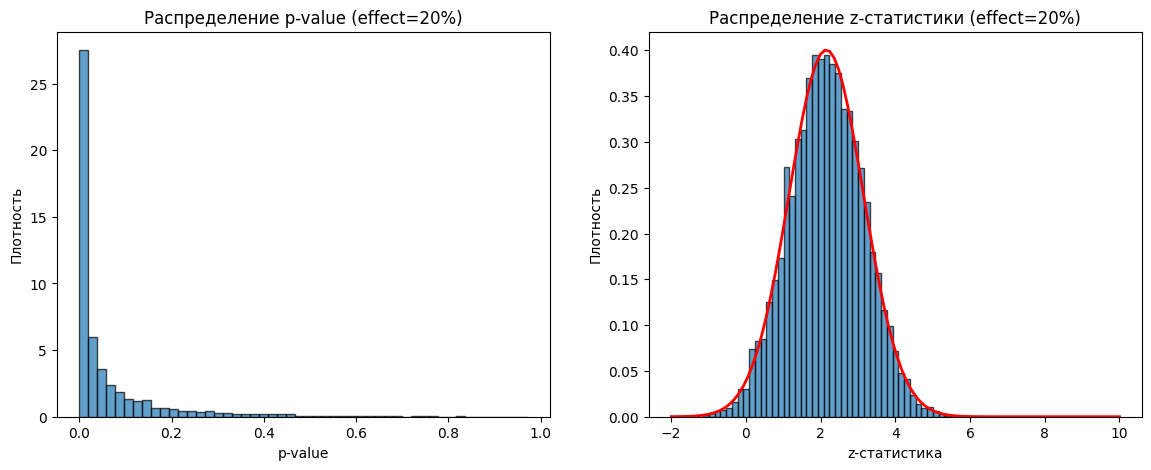

In [7]:
effect_20 = 0.2
z_values_20 = []
p_values_20 = []

for _ in range(n_sim):
    x_control, x_treatment = gen_sample(n_obs, effect_20, p_control)
    z_obs, p_val = asy_mean_test(x_control, x_treatment, alternative='larger')
    z_values_20.append(z_obs)
    p_values_20.append(p_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(p_values_20, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение p-value (effect=20%)')

axes[1].hist(z_values_20, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(-2, 10, 100)
axes[1].plot(x, stats.norm.pdf(x, np.mean(z_values_20), np.std(z_values_20)), 'r-', lw=2)
axes[1].set_xlabel('z-статистика')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение z-статистики (effect=20%)')

А как будут выглядеть результаты, если доля в тестовой выборке больше на $40\%$? Проведите симуляции.

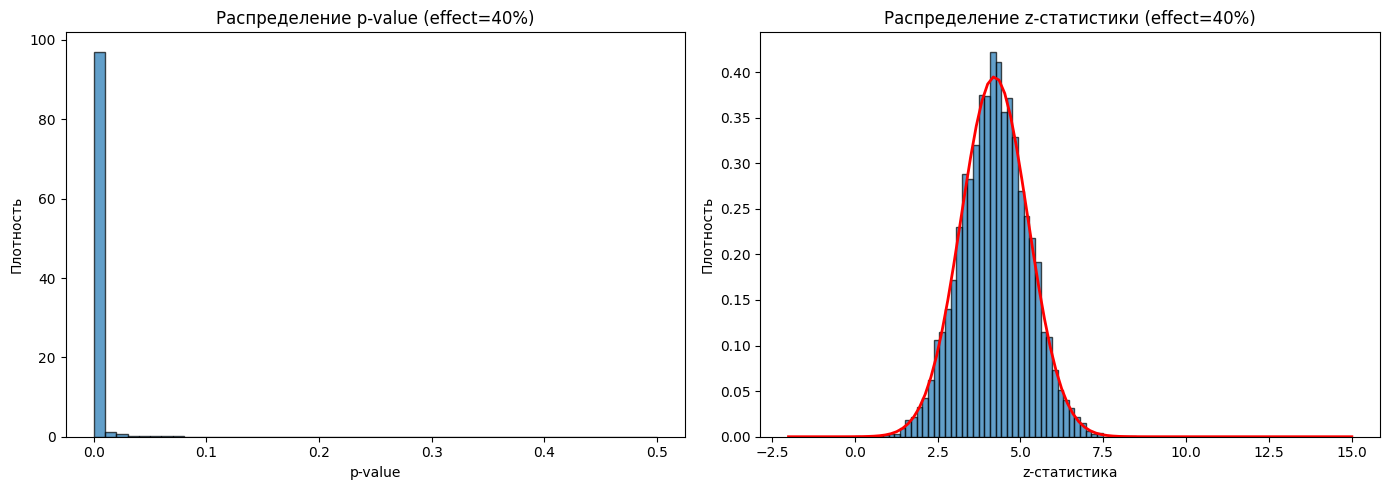

In [8]:
effect_40 = 0.4
z_values_40 = []
p_values_40 = []

for _ in range(n_sim):
    x_control, x_treatment = gen_sample(n_obs, effect_40, p_control)
    z_obs, p_val = asy_mean_test(x_control, x_treatment, alternative='larger')
    z_values_40.append(z_obs)
    p_values_40.append(p_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(p_values_40, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение p-value (effect=40%)')

axes[1].hist(z_values_40, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(-2, 15, 100)
axes[1].plot(x, stats.norm.pdf(x, np.mean(z_values_40), np.std(z_values_40)), 'r-', lw=2)
axes[1].set_xlabel('z-статистика')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение z-статистики (effect=40%)')

plt.tight_layout()
plt.show()

In [9]:
print(f"Effect 20% - Среднее z: {np.mean(z_values_20):.4f}, Доля p-value < 0.05: {np.mean(np.array(p_values_20) < 0.05):.4f}")
print(f"Effect 40% - Среднее z: {np.mean(z_values_40):.4f}, Доля p-value < 0.05: {np.mean(np.array(p_values_40) < 0.05):.4f}")

Effect 20% - Среднее z: 2.1525, Доля p-value < 0.05: 0.6965
Effect 40% - Среднее z: 4.2147, Доля p-value < 0.05: 0.9945


Правда ли, что распределение `pvalue` оказалось равномерным на отрезке $[0;1]$? Какое у распределения `z_obs` математическое ожидание? Попытайтесь понятными словами пояснить, почему распределения оказались именно такими.

__Ответ:__

Распределение pvalue не расномерное и в большей степени смещено к 0 (чем сильнее эффект). Математическое ожидание не равно 0 (2.15 для 20%, 4.21 для 40%).

Z_obs имеет нормальное распределение (по ЦПТ) с: Матожиданием = реальная разность средних/стандартная ошибка и Дисперсией = 1.  Отсюда чем больше эффект, тем дальше от нуля матожидание z_obs и меньше pvalue.

__г) [1 балл]__ Обычно, перед началом эксперимента, мы фиксируем ошибку первого рода, вероятность отвергнуть нулевую гипотезу, когда она на самом деле верна,  

$$\alpha = \mathbb{P}(H_A \text{ выбрана} \mid H_0 \text{ верна}).$$

Дальше мы принимаем решение, о том, какую гипотезу выбрать, сравнивая `z_obs` с $z_{1 - \alpha},$ либо `pvalue` с $\alpha$ (напомню что мы делаем симуляции для правосторонней альтернативы, поэтому $\alpha$ не надо делить на два).

Давайте проверим для конкретного $\alpha$, что это правда работает. Выберите любое разумное значение $\alpha$. С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$ при верности нулевой гипотезы. Проверьте эти гипотезы и оцените получившееся значение $\alpha$. Правда ли, что оно оказалось равно заявленному значению?

__P.S.__ в идеале, тут надо воспользоваться уже проделанными выше симуляциями.

In [10]:
alpha = 0.05

alpha_estimated = np.mean(np.array(p_values) < alpha)
print(f"Заданная alpha = {alpha}")
print(f"Оцененная alpha = {alpha_estimated}")

Заданная alpha = 0.05
Оцененная alpha = 0.0487


Кроме ошибки первого рода есть ещё и ошибка второго рода, вероятность остаться с нулевой гипотезой, когда верна альтернатива,

$$\beta = \mathbb{P}(H_0 \text{ выбрана} \mid H_A \text{ верна}).$$

Давайте предположим, что доля в тестовой (treatment) выборке оказалась на $20\%$ больше, чем в контрольной. С помощью симуляций того же самого объёма оцените, чему равна $\beta$.

__P.S.__ в идеале, тут надо воспользоваться уже проделанными выше симуляциями.

In [11]:
beta_20 = np.mean(np.array(p_values_20) >= alpha)
power_20 = 1 - beta_20
print(f"Для эффекта 20%:")
print(f"beta = {beta_20}")
print(f"Мощность (1-beta) = {power_20}")

Для эффекта 20%:
beta = 0.3035
Мощность (1-beta) = 0.6965


Теперь доля в тестовой выборке оказалась на $40\%$ больше, чем в контрольной. Чем равна $\beta$ здесь?

In [12]:
beta_40 = np.mean(np.array(p_values_40) >= alpha)
power_40 = 1 - beta_40
print(f"Для эффекта 40%:")
print(f"beta = {beta_40:.4f}")
print(f"Мощность (1-beta) = {power_40:.4f}")

Для эффекта 40%:
beta = 0.0055
Мощность (1-beta) = 0.9945


Что с ошибкой второго рода происходит при росте эффекта? Что происходит с ней, если при проверке гипотезы взять более маленькое $\alpha$?

__Ответ:__

1) Ошибка второго рода beta уменьшается при росте эффекта.

   Ошибка второго рода по сути представляет собой вероятность не заметить реально существующий эффект, то есть ошибочно принять нулевую гипотезу, когда на самом деле верна альтернатива.

   А мы видим, что чем больше эффект, тем дальше распределение тестовой статистики при H1 от распределения при H0.

2) При уменьшении alpha ошибка второго рода beta увеличивается. Аlpha и beta связаны обратной зависимостью.


__д) [1 балл]__ Ошибки $\alpha$ и $\beta$ связаны между собой. Чем выше, при фиксированном размере выборки и эффекта мы делаем одну, тем ниже другая. Давайте попробуем в рамках проделанных выше симуляций нарисовать взаимосвязь между ошибками.

Выше, для оценки $\beta$ вы сравнивали вектор `pval` с зафиксированным значением `alpha`.  Переберите `alpha` по циклу от 0 до 1 с шагом 0.01 и оцените для каждого значения `alpha` значение `beta`.

Нарисуйте получившуюся взаимосвязь на графике для эффекта в 20% и 40%. Какая из кривых идёт ниже?

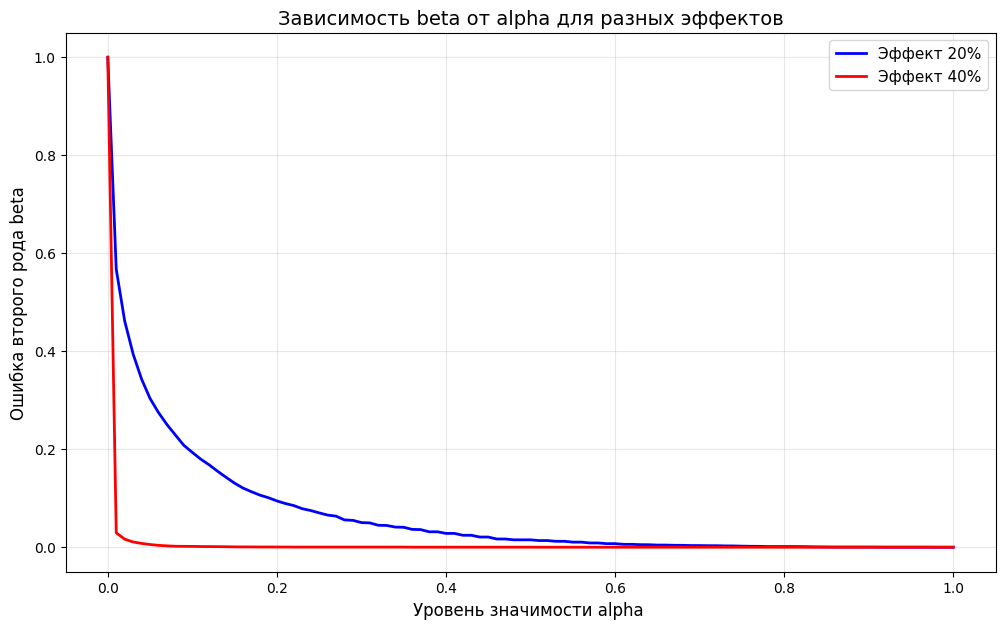

In [13]:
alphas = np.arange(0, 1.01, 0.01)

beta_20 = []
beta_40 = []

for alpha in alphas:
    beta_20.append(np.mean(p_values_20 >= alpha))
    beta_40.append(np.mean(p_values_40 >= alpha))

beta_20 = np.array(beta_20)
beta_40 = np.array(beta_40)

plt.figure(figsize=(12, 7))
plt.plot(alphas, beta_20, 'b-', linewidth=2, label='Эффект 20%')
plt.plot(alphas, beta_40, 'r-', linewidth=2, label='Эффект 40%')
plt.xlabel('Уровень значимости alpha ', fontsize=12)
plt.ylabel('Ошибка второго рода beta', fontsize=12)
plt.title('Зависимость beta от alpha для разных эффектов', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

Ответ:

Кривая для эффекта 40% идёт ниже кривой для эффекта 20%. Это означает, что при одном и том же alpha ошибка второго рода beta меньше для большего эффекта.

Нарисуйте точно такую же кривую для ситуации, когда была верна нулевая гипотеза.

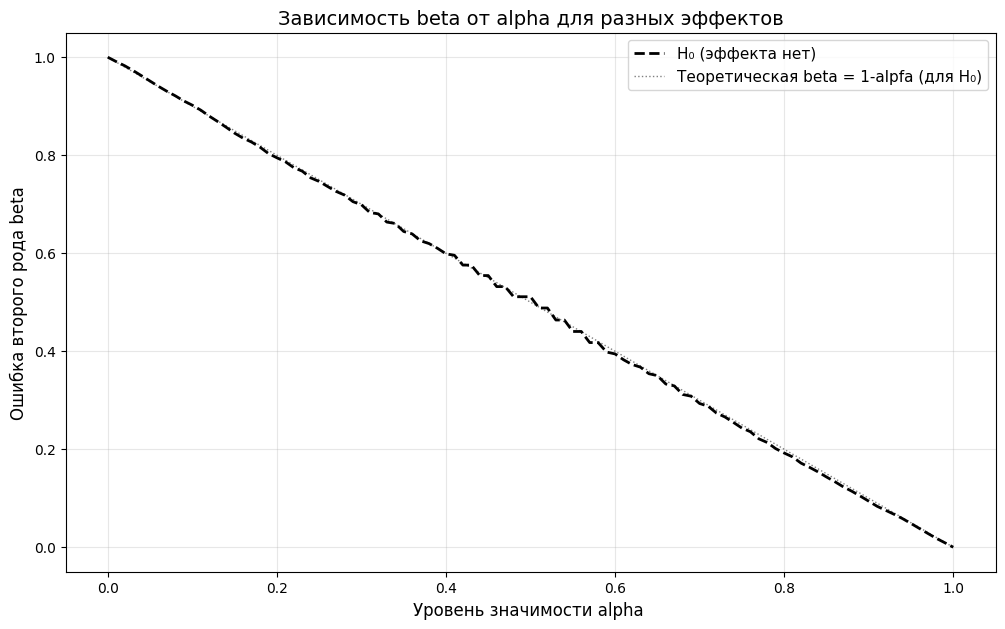

In [14]:
beta_h0 = []
for alpha in alphas:
    beta_h0.append(np.mean(p_values >= alpha))

beta_h0 = np.array(beta_h0)
plt.figure(figsize=(12, 7))

plt.plot(alphas, beta_h0, 'k--', linewidth=2, label='H₀ (эффекта нет)')
plt.plot(alphas, 1 - alphas, 'k:', linewidth=1, alpha=0.5, label='Теоретическая beta = 1-alpfa (для H₀)')
plt.xlabel('Уровень значимости alpha ', fontsize=12)
plt.ylabel('Ошибка второго рода beta', fontsize=12)
plt.title('Зависимость beta от alpha для разных эффектов', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)


Вместо осей $(\alpha, \beta)$ обычно такой график рисуют в осях $(\alpha, 1 - \beta)$. Давайте построим его и проинтерпретируем.

In [15]:
def plot_pvalue_distribution(dict_pvalues):
    xseq = np.linspace(0, 1, 1000)

    for key, pvalues in dict_pvalues.items():
        yseq = [np.mean(pvalues < x) for x in xseq]
        plt.plot(xseq, yseq, label=key)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Распределение p-value/ROC-кривая', size=16)
    plt.xlabel('alpha', size=12)
    plt.ylabel('1 - beta', size=12)
    plt.legend(fontsize=12)
    plt.grid()

Заполните пропуски в коде ниже, чтобы для нашего АБ-теста отрисовались ROC-кривые.

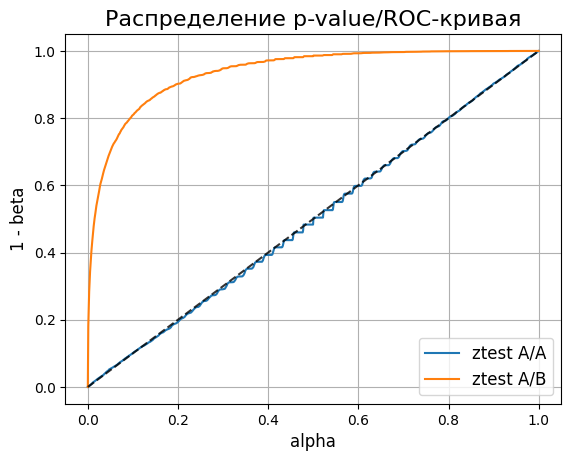

In [16]:
n_sim = 10**4
sample_size = 1000

dict_pvalues = defaultdict(list)
for _ in range(n_sim):

    x_control, x_treatment = gen_sample(sample_size, 0.2, 0.2)
    z_obs_ab, pval_ab = asy_mean_test(x_control, x_treatment, alternative='larger')

    # сгенерируем ещё одну тестовую выборку, чтобы убедиться, что в случае когда выборки совпали,
    # наш тест работает корректно и не находит разницу

    x_control_again, _ = gen_sample(1000, 0, 0.2)
    z_obs_aa, pval_aa = asy_mean_test(x_control, x_control_again)

    dict_pvalues['ztest A/A'].append(pval_aa)
    dict_pvalues['ztest A/B'].append(pval_ab)

plot_pvalue_distribution(dict_pvalues)

Получившийся график можно проинтерпретировать двумя способами. Мы много-много раз проводим АБ-тест. В начале теста мы зафиксировали какую-то $\alpha$ и дальше проверяем кучу гипотез.

1. Линия `ztest A/A` это функция распределения pvalue при верности нулевой гипотезы. Оно было равномерным, мы двигаем $\alpha$ по оси $OX$ и оцениваем $\mathbb{P}(\text{pvalue} \le \alpha) = F(\alpha)$.  

По аналогии, линия `ztest A/B` это функция распределения pvalue при верности альтернативной гипотезы.

2. Линию `ztest A/B` можно проинтерпретировать как ROC-кривую. Если вы уже знаете про задачу классификации из машинного обучения, то это ровно оно. Полнота это $1 - \beta$, то есть то, сколько верных альтернативных гипотез мы найдём, если будем использовать наш АБ-тест, FPR это $\alpha$, то есть то, сколько верных нулевых гипотез мы заберём с собой в альтернативные. Эту величину мы определяем до старта эксперимента.

> Важно: если вы не поняли интерпретацию из пункта 2, просто забейте. Заботаете МО, поймёте. Интерпретацию из пункта 1 должны понять все. Если вы её не поняли, время напрячься и подумать ещё разок.

__Что для нас важно:__

- Чем выпуклее график, тем лучше мы находим эффект и процедура проверки гипотезы работае корректно;
- Чем больше у нас наблюдений тем выпуклее график;
- Чем сильнее в тестовой выборке подскакивает $p_t$ при изменениях, тем легче нам найти эффект и тем выпуклее график;
- Если $p_t$ подскочило на очень маленькую величину, нам сложнее найти это изменение, и график будет менее выпуклым;
- Чем меньше в выборках дисперсия, тем выпуклее график.

__е) [2 балла]__ При верности альтернативной гипотезы, постройте ROC-кривые из пункта выше для разного числа наблюдений в выборке: 10, 100, 1000, 10000 при любом фиксированном эффекте.

/tmp/ipykernel_8728/3317719249.py:13: RuntimeWarning: invalid value encountered in scalar divide
  z_obs = (mean_t-mean_c)/se


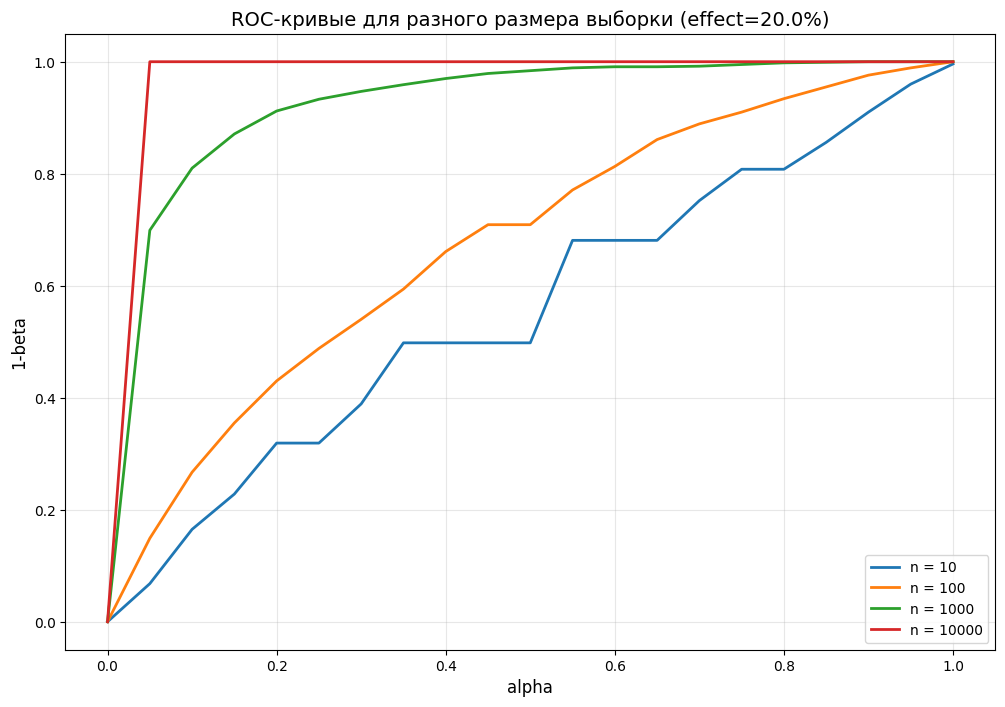

In [17]:
sample_sizes = [10, 100, 1000, 10000]
effect = 0.2
alphas_grid = np.arange(0, 1.01, 0.05)

plt.figure(figsize=(12, 8))

for n in sample_sizes:
    p_values_n = []
    for _ in range(1000):
        x_control, x_treatment = gen_sample(n, effect, p_control)
        _, p_val = asy_mean_test(x_control, x_treatment, alternative='larger')
        p_values_n.append(p_val)

    power_curve = []
    for a in alphas_grid:
        power_curve.append(np.mean(np.array(p_values_n) < a))

    plt.plot(alphas_grid, power_curve, label=f'n = {n}', linewidth=2)

plt.xlabel('alpha', fontsize=12)
plt.ylabel('1-beta', fontsize=12)
plt.title(f'ROC-кривые для разного размера выборки (effect={effect*100}%)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

__ё) [1 балл]__ Количество наблюдений, ошибка 1 и 2 рода, размер эффекта, который мы ищем и дисперсия в выборках связаны между собой. Для некоторых критериев проверки гипотез можно вывести формулы, которые их связывают.

В данном случае, формула для расчета числа наблюдений _для одной группы_ выглядит вот так:

$$
n_{\text{one group}} = \frac{(\sigma_A^2 + \sigma_B^2) \cdot (z_{1-\frac{\alpha}{2}} + z_{1-\beta})^2}{MDE^2},
$$

В приложении Яндекс.Такси в конце поездки вылезают рандомные опросники. В одном из опросников задаётся вопрос «А вы пристёгивались, когда ехали?»

В России, в день, в Такси происходит 1 миллион заказов. Вопрос про ремни задаётся рандомным 10% пользователей, закончивших поездку. Пользователь не игнорирует опросник и отвечает на него да или нет с вероятностью 5% (цифры взяты из головы и не отражают реальную статистику).

Менеджер Екатерина хочет сделать так, чтобы когда пассажир садится в машину, Алиса просила его пристегнуться. Хочется замерить, какой эффект это даст на пристёгивания. Станут ли люди чаще пристёгиваться. Замерять мы это будем опросником. Сейчас 10% пользователей говорят, что пристегнулись.

Екатерина пришла к вам и между вами состоялся следующий диалог:

- Хочу АБ-тест с разбивкой 50 на 50.
- Какие ошибки 1 и 2 рода хочешь?
- Нулевые.
- Нам надо бесконечно наблюдений, готова столько ждать?
- Нет.
- На сколько мы хотим, чтобы выросла доля ответов да?
- Если подрастёт хотябы на процент, будет круто.
- То есть если меньше процента, такой эффект считаем неудачей и отсутствием изменения?
- Да.
- Давай я нарисую тебе табличку с разными ошибками, а внутри на пересечении напишу сколько дней надо ждать, чтобы найти такой минимальный эффект.
- Давай, по ней и примем решение.

Нарисуйте для Екатерины такую табличку. Не забудьте перевести общее количество наблюдений в дни.

In [23]:
total_orders_per_day = 1_000_000
survey_view_rate = 0.10
survey_response_rate = 0.05

daily_responses = total_orders_per_day * survey_view_rate * survey_response_rate

p1= 0.10
mde= 0.01
p2= p1 + mde

var1 = p1*(1-p1)
var2 = p2*(1-p2)

def calculate_days(alpha, beta):
    z_alpha = norm.ppf(1-alpha/2)
    z_beta= norm.ppf(1-beta)
    n_one_group = (var1+var2)*(z_alpha+z_beta)**2 /(mde**2)
    total_n= n_one_group*2
    days = total_n/daily_responses
    return days

alphas = [0.10, 0.05, 0.01]
betas = [0.20, 0.10, 0.05]

results = []
for b in betas:
    row = []
    for a in alphas:
        row.append(round(calculate_days(a, b), 1))
    results.append(row)

df = pd.DataFrame(results,
                  index=[f'Power {int((1-b)*100)}% (beta={b})' for b in betas],
                  columns=[f'Alpha {a}' for a in alphas])

print("\nТаблица: Количество дней для проведения теста")
print(df)


Таблица: Количество дней для проведения теста
                       Alpha 0.1  Alpha 0.05  Alpha 0.01
Power 80% (beta=0.2)         4.6         5.9         8.8
Power 90% (beta=0.1)         6.4         7.9        11.2
Power 95% (beta=0.05)        8.1         9.8        13.4


__ж) [1 балл]__ Попробуем сломать наш АБ-тест. Когда мы используем z-тест, мы размышляем в терминах центральной предельной теоремы. Тест будет работать, если выполнены предпосылки ЦПТ:

- Наблюдения независимо одинаково распределены
- В данных нет выборосов, дисперсия конечная
- Данных много

Давайте сломаем одно из условий и попробуем собрать выборку из [распределения Парето](https://ru.wikipedia.org/wiki/Распределение_Парето).

In [26]:
def gen_sample(n_obs, effect, b=0.5):
    x_control = stats.pareto(b=b).rvs(n_obs)
    x_treatment = stats.pareto(b=b).rvs(n_obs)
    x_treatment = (1 + effect) * x_treatment
    return x_control, x_treatment

Отрисуйте ROC-кривые для $b=3$, $b=1$, $b=0.5$

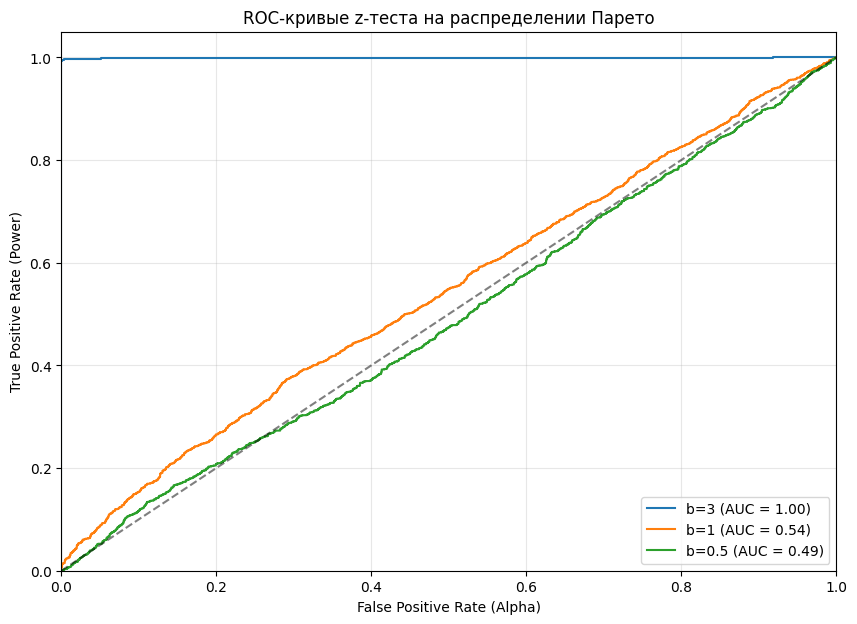

In [31]:
def get_p_values(n_obs, effect, b, iterations=1000):
    p_values = []
    for _ in range(iterations):
        xc, xt = gen_sample(n_obs, effect, b)
        _, p_val = stats.ttest_ind(xc, xt, equal_var=False)
        p_values.append(p_val)
    return np.array(p_values)

n_obs = 1000
effect_size = 0.2
b_values = [3, 1, 0.5]
iterations = 2000

plt.figure(figsize=(10, 7))

for b in b_values:
    p_h0 = get_p_values(n_obs, 0, b, iterations)
    p_h1 = get_p_values(n_obs, effect_size, b, iterations)

    y_true = np.array([0] * iterations + [1] * iterations)
    y_scores = np.concatenate([1 - p_h0, 1 - p_h1])

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'b={b} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Alpha)')
plt.ylabel('True Positive Rate (Power)')
plt.title('ROC-кривые z-теста на распределении Парето')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Возьмите при каждом $b$ одну выборку, нарисуйте для неё гистограмму и посмотрите как обстоят дела с выбросами.

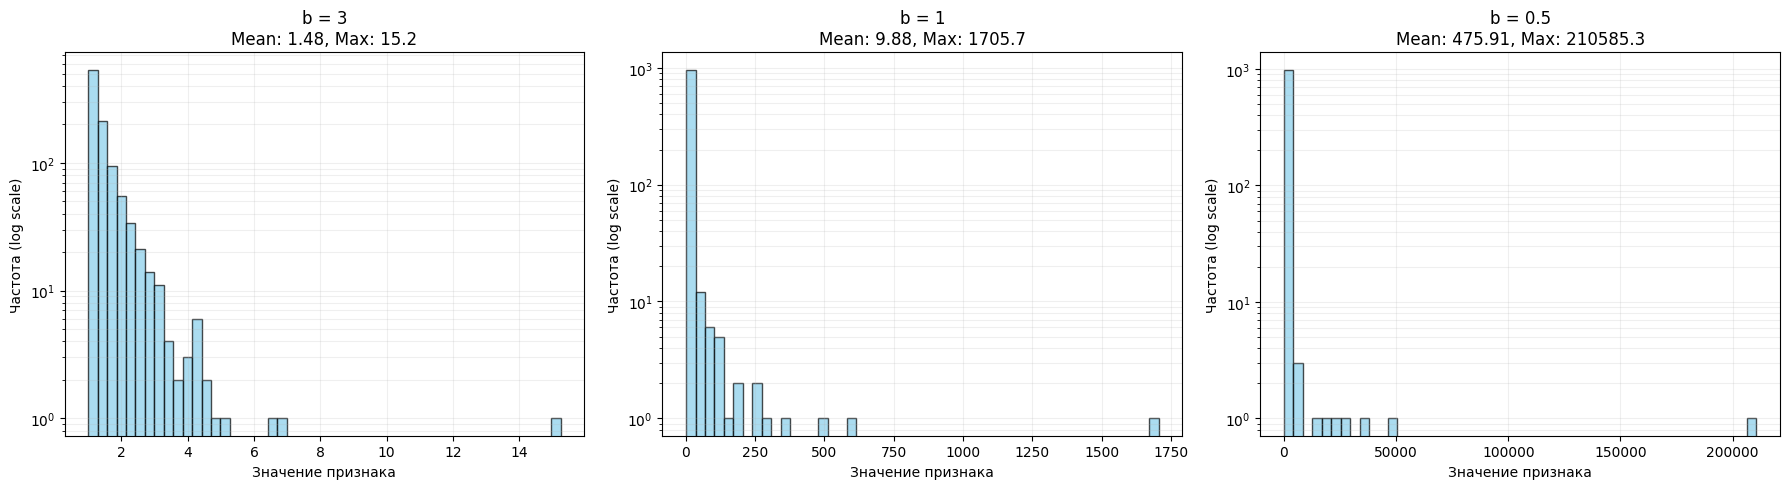

In [30]:
np.random.seed(42)

n_obs = 1000
b_values = [3, 1, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, b in enumerate(b_values):
    sample = stats.pareto(b=b).rvs(n_obs)
    mean_val = np.mean(sample)
    max_val = np.max(sample)
    std_val = np.std(sample)

    axes[i].hist(sample, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'b = {b}\nMean: {mean_val:.2f}, Max: {max_val:.1f}')
    axes[i].set_yscale('log')
    axes[i].set_xlabel('Значение признака')
    axes[i].set_ylabel('Частота (log scale)')
    axes[i].grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

У распределения Парето не всегда существует дисперсия. Это ломает предпосылки ЦПТ и АБ-тест разваливается.

Возникает вполне резонный вопрос: а что делать в таких ситуациях? Есть несколько дорог.

- Во-первых, можно отвязаться от математического ожидания и поработать с медианой. Для неё тоже можно вывести асимптотическое распределение с помощью дельта-метода.
- Во-вторых, можно попробовать другие техники проверки гипотез. Например, бутстрап и непараметрические критерии.

Об этом мы и будем говорить на следующих парах.